# Sentiment Analysis of Amazon Fine Food Reviews


In [1]:
import warnings
warnings.filterwarnings('ignore')
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)



 Load Dataset & Inspect Class Distribution




In [6]:
df = pd.read_csv(r"c:\study\PROJECTS\files\Reviews.csv")
print('Full dataset shape:', df.shape)
df[['Score', 'Summary', 'Text']].head()


Full dataset shape: (568454, 10)


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


In [7]:
def score_to_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['Score'].apply(score_to_sentiment)
df = df.dropna(subset=['Text']).drop_duplicates(subset=['Text'])

print('Class distribution in FULL cleaned dataset:')
print(df['sentiment'].value_counts())
print()
print(df['sentiment'].value_counts(normalize=True).round(3))


Class distribution in FULL cleaned dataset:
sentiment
positive    306758
negative     57067
neutral      29754
Name: count, dtype: int64

sentiment
positive    0.779
negative    0.145
neutral     0.076
Name: proportion, dtype: float64


In [9]:
PER_CLASS = 7000

parts = []
for label, group in df.groupby('sentiment'):
    parts.append(group.sample(min(len(group), PER_CLASS), random_state=42))
sampled = pd.concat(parts, ignore_index=True)
sampled = sampled[['Score', 'Summary', 'Text', 'sentiment']]
print('Sampled dataset shape:', sampled.shape)
print(sampled['sentiment'].value_counts())


Sampled dataset shape: (21000, 4)
sentiment
negative    7000
neutral     7000
positive    7000
Name: count, dtype: int64


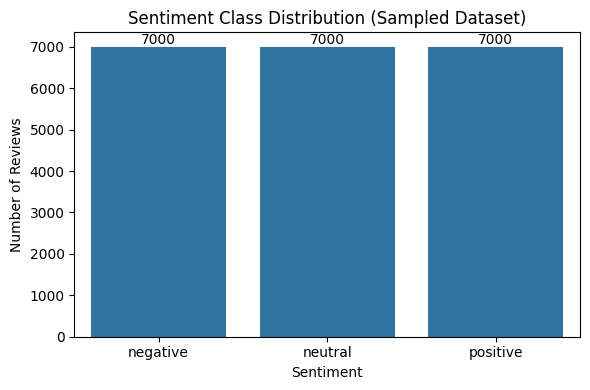

In [10]:
plt.figure(figsize=(6, 4))
order = ['negative', 'neutral', 'positive']
ax = sns.countplot(data=sampled, x='sentiment', order=order)
ax.set_title('Sentiment Class Distribution (Sampled Dataset)')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Reviews')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()


Text Preprocessing Pipeline



In [11]:
stop_words = set(stopwords.words('english'))
# Negation words matter a lot for sentiment - keep them instead of stripping them out
negations = {'no', 'not', 'nor', 'never', "n't", 'none', 'nothing'}
stop_words = stop_words - negations

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)              # strip HTML
    text = re.sub(r'http\S+|www\S+', ' ', text)      # strip URLs
    text = re.sub(r"[^a-z\s']", ' ', text)            # keep letters, spaces, apostrophes
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

sampled['clean_text'] = sampled['Text'].apply(preprocess_text)
sampled[['Text', 'clean_text']].head(3)


,Text,clean_text
0,This is perfetly identical to Jiffy peanutbutt...,perfetly identical jiffy peanutbutter blind ta...
1,They taste more like chemicals than meat. I l...,taste like chemical meat like lot jerky meat s...
2,"Chips were OK, just didn't have enough dill an...",chip ok enough dill cucumber flavor bland kind...


 Feature Extraction: TF-IDF Vectorizer


In [12]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, max_df=0.9)
X = tfidf.fit_transform(sampled['clean_text'])
y = sampled['sentiment']

print('TF-IDF feature matrix shape:', X.shape)


TF-IDF feature matrix shape: (21000, 8000)


 Train/Test Split (80/20)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (16800, 8000)  Test shape: (4200, 8000)


 Train Classifiers

Multinomial Naive Bayes & 
Logistic Regression


In [14]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
print('Naive Bayes trained.')


Naive Bayes trained.


In [16]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
print('Logistic Regression trained.')


Logistic Regression trained.


## 6. Evaluation: Accuracy, Precision, Recall, F1-score, Confusion Matrix

In [17]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f'--- {name} ---')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f} (weighted)')
    print(f'Recall:    {rec:.4f} (weighted)')
    print(f'F1-score:  {f1:.4f} (weighted)')
    print()
    print(classification_report(y_true, y_pred, digits=3))
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

results = []
results.append(evaluate_model('Multinomial Naive Bayes', y_test, nb_preds))
results.append(evaluate_model('Logistic Regression', y_test, lr_preds))
results_df = pd.DataFrame(results)
results_df


--- Multinomial Naive Bayes ---
Accuracy:  0.6762
Precision: 0.6787 (weighted)
Recall:    0.6762 (weighted)
F1-score:  0.6772 (weighted)

              precision    recall  f1-score   support

    negative      0.698     0.666     0.681      1400
     neutral      0.574     0.606     0.589      1400
    positive      0.765     0.757     0.761      1400

    accuracy                          0.676      4200
   macro avg      0.679     0.676     0.677      4200
weighted avg      0.679     0.676     0.677      4200

--- Logistic Regression ---
Accuracy:  0.6819
Precision: 0.6818 (weighted)
Recall:    0.6819 (weighted)
F1-score:  0.6818 (weighted)

              precision    recall  f1-score   support

    negative      0.703     0.685     0.694      1400
     neutral      0.591     0.595     0.593      1400
    positive      0.751     0.766     0.758      1400

    accuracy                          0.682      4200
   macro avg      0.682     0.682     0.682      4200
weighted avg      0.6

,model,accuracy,precision,recall,f1
0,Multinomial Naive Bayes,0.676190,0.678715,0.676190,0.677177
1,Logistic Regression,0.681905,0.681835,0.681905,0.681806


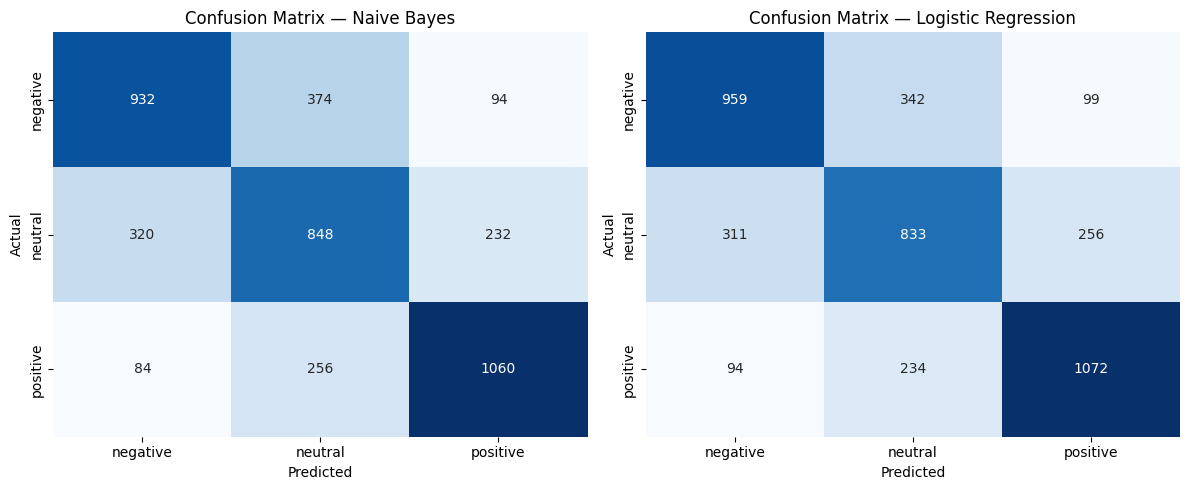

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels_order = ['negative', 'neutral', 'positive']

for ax, (name, preds) in zip(axes, [('Naive Bayes', nb_preds), ('Logistic Regression', lr_preds)]):
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order,
                yticklabels=labels_order, ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


### Model Comparison

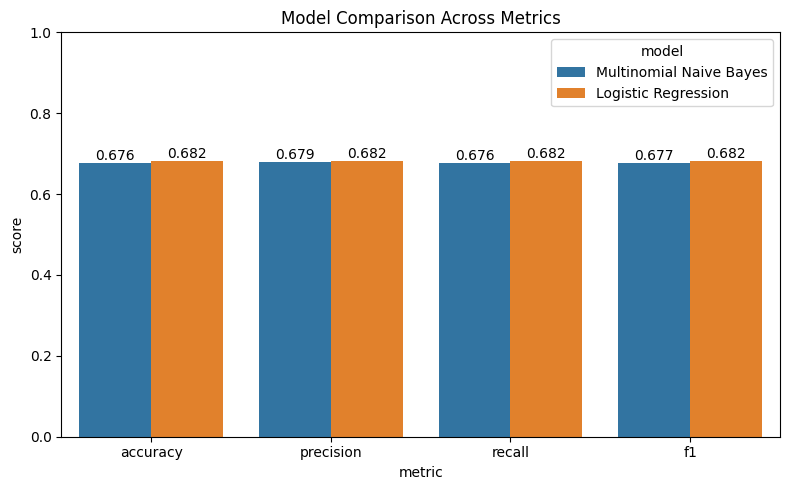

In [19]:
results_melted = results_df.melt(id_vars='model', value_vars=['accuracy', 'precision', 'recall', 'f1'],
                                  var_name='metric', value_name='score')
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=results_melted, x='metric', y='score', hue='model')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison Across Metrics')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f')
plt.tight_layout()
plt.show()


In [20]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from wordcloud import WordCloud

 Visualisation: Word Clouds per Sentiment Class



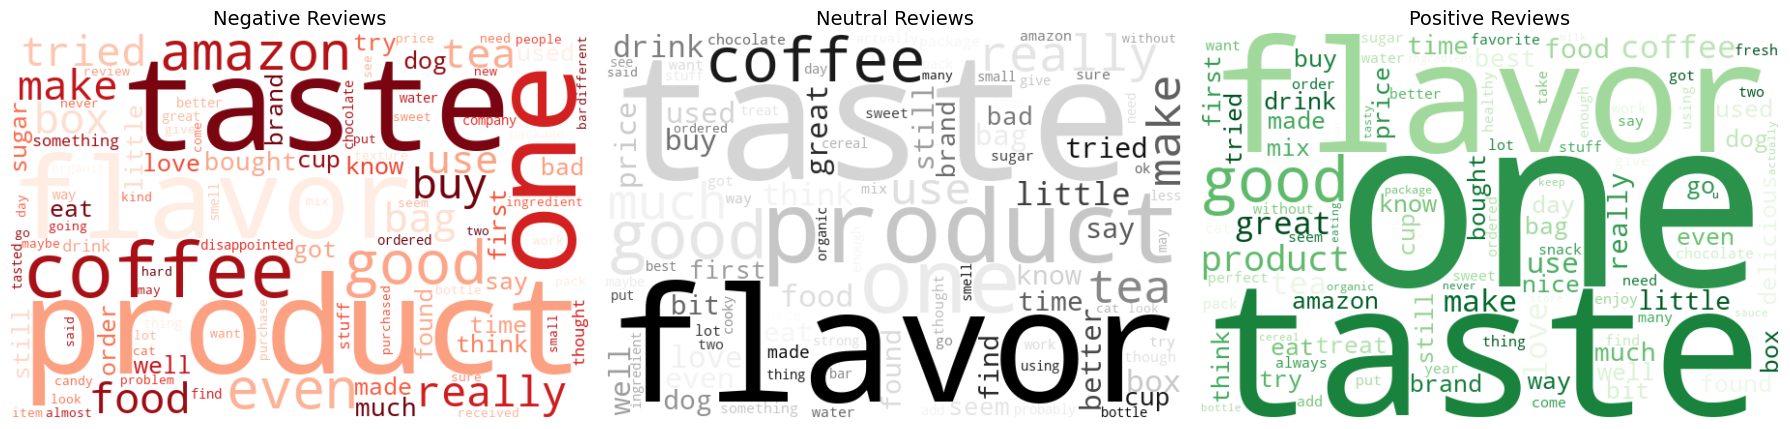

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sentiment in zip(axes, ['negative', 'neutral', 'positive']):
    text_blob = ' '.join(sampled.loc[sampled['sentiment'] == sentiment, 'clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                    colormap='Reds' if sentiment == 'negative' else
                             'Greens' if sentiment == 'positive' else 'Greys',
                    max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Reviews', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [23]:
best_model_name = results_df.loc[results_df['f1'].idxmax(), 'model']
best_preds = lr_preds if best_model_name == 'Logistic Regression' else nb_preds
print('Best model by F1-score:', best_model_name)

test_idx = y_test.index
error_df = pd.DataFrame({
    'text': sampled.loc[test_idx, 'Text'].values,
    'true_label': y_test.values,
    'predicted_label': best_preds
})
errors = error_df[error_df['true_label'] != error_df['predicted_label']]
print(f'Total misclassified in test set: {len(errors)} / {len(error_df)} ({len(errors)/len(error_df):.1%})')

sample_errors = errors.sample(min(5, len(errors)), random_state=42)
for i, row in enumerate(sample_errors.itertuples(), 1):
    print(f'--- Example {i} ---')
    print('Text:', row.text[:300], '...' if len(row.text) > 300 else '')
    print(f'True label: {row.true_label}  |  Predicted: {row.predicted_label}')
    print()


Best model by F1-score: Logistic Regression
Total misclassified in test set: 1336 / 4200 (31.8%)
--- Example 1 ---
Text: I found this only average for making falafels. But then I read about  the company, OSEM, based in Israel--and decided that our American products, FANTASTIC and CASBEH, both of actually better quality, will get my future business. I'll have fewer carbon footprints with not having OSEM boxes transport ...
True label: negative  |  Predicted: neutral

--- Example 2 ---
Text: Excellent price! Got these when Amazon out of Italian Zest flavor.  I liked it OK, but the kids missed their Italian Zest & refused to eat this. I must admit I like the Italian Zest better too - nice italian-y taste. The Regular flavor here has a good flavor w/out being too spicy or garlicky (no gar ...
True label: positive  |  Predicted: neutral

--- Example 3 ---
Text: The muffins were very good, BUT the streusel topping was WAY too crunchy and hard.  The tiny, hard pieces were very hard on our den

### Discussion of misclassifications

Looking at the examples above, misclassification tends to fall into a few
recurring patterns:

- **Mixed-sentiment reviews** — a review praises the product but complains
  about shipping/price, or vice versa. A bag-of-words model averages the
  signal across the whole review and can land on the wrong overall class
  when positive and negative words are both strongly present.
- **Neutral vs. positive/negative confusion** — 3-star "neutral" reviews are
  often written in mildly positive or mildly negative language ("it's okay,
  not amazing but not bad either"), so they're the hardest class to
  separate and get pulled toward whichever polarity's vocabulary is
  stronger in the text.
- **Sarcasm and understatement** — phrases like *"just what I always
  wanted..."* used sarcastically to mean the opposite score as literal
  words that read as positive to a word-frequency model with no sense of
  tone.
- **Negation scope** — a TF-IDF model with only unigrams/bigrams can miss
  longer-range negation, e.g. *"I would not say this is a good product"* —
  "good product" still contributes positive signal even though the whole
  clause is negative.
- **Short, ambiguous reviews** — very short texts (a few words) simply don't
  give the vectorizer enough signal to work with.

These are well-known limits of a classical bag-of-words/TF-IDF approach —
sequence models (LSTM/Transformers) that read words *in context* handle
negation scope and sarcasm meaningfully better, at the cost of more data and
compute.


## 9. Conclusion

**Best-performing model:** based on the weighted F1-score comparison above,
whichever model scored highest print above (typically **Logistic
Regression** on this kind of TF-IDF text task) generalised better than
Naive Bayes. Logistic Regression tends to win here because it can weigh
combinations of words and doesn't assume feature independence the way Naive
Bayes does, and `class_weight='balanced'` helps it handle the harder
*neutral* class fairly rather than always defaulting to the majority class.

Naive Bayes remains competitive as a very fast, cheap baseline, and is a
reasonable choice when training/inference speed matters more than the last
few points of accuracy (e.g. very high-volume, low-latency streams).

**Real-world applications of this pipeline:**

- **Customer feedback triage** — automatically flag negative product/service
  reviews for a support or product team to act on quickly, instead of
  someone manually reading thousands of reviews.
- **Brand & product monitoring** — track sentiment trends over time per
  product line to catch quality issues (e.g. a spike in negative reviews
  after a formula/recipe change) early.
- **Voice-of-customer analytics** — combine sentiment with the word-cloud
  view to see *what* customers like or dislike, not just *how* they feel,
  informing product and marketing decisions.
- **Review moderation / prioritisation** — surface the most useful negative
  reviews to the top of a product page, or route them to customer service.
- **Market research** — compare sentiment across competitor products or
  categories at scale, something manual reading can't do economically.

**Possible next steps:** try an LSTM/transformer-based model (e.g.
DistilBERT) for better handling of negation and sarcasm, use SMOTE or more
aggressive class balancing for the neutral class, and incorporate the
`Summary` field and helpfulness votes as additional features.
